## Cell 1: Install and Import Libraries

So in this first cell I'm basically setting up everything I need to run the project.

I'm installing the libraries first using pip, then importing them so I can actually use them in the code.

- I'm importing **re** so I can clean the text later using patterns
- **pandas and numpy** are for loading and working with the dataset
- **matplotlib and seaborn** are what I'm using to make the charts
- **tqdm** just shows me a progress bar so I can see how far along the cleaning is
- **nltk** is the main library I'm using for all the text processing like removing stop words and lemmatizing
- The **sklearn** imports are all the machine learning stuff — the models, the vectorizer, and the metrics I need to evaluate everything

In [ ]:
!pip install -q nltk pandas numpy scikit-learn matplotlib seaborn tqdm

import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from tqdm.notebook import tqdm

import nltk
for pkg in ['stopwords', 'wordnet', 'vader_lexicon', 'punkt', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

from nltk.corpus          import stopwords
from nltk.stem            import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.model_selection         import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes             import BernoulliNB
from sklearn.svm                     import LinearSVC
from sklearn.linear_model            import LogisticRegression
from sklearn.pipeline                import Pipeline
from sklearn.metrics                 import (classification_report,
                                              confusion_matrix,
                                              accuracy_score,
                                              mean_absolute_error)
print('All libraries loaded!')

All libraries loaded!


## Cell 2: Load the Dataset

Here I'm loading the Reviews.csv file into a DataFrame so I can work with it.

I'm only keeping the 4 columns I actually need which are review_id, Score, Summary, and Text. I'm also dropping any rows where the Score or Text is missing because those would cause issues later.

I sampled it down to 20,000 rows because the full dataset has over 500,000 reviews and that would take way too long to run in Colab. I used random_state=42 so I get the same sample every time I run it.

At the end I'm just printing some info about the data to make sure everything loaded correctly.

In [ ]:
df = pd.read_csv('Reviews.csv')

df['review_id'] = range(1, len(df) + 1)
df = df[['review_id', 'Score', 'Summary', 'Text']]
df.dropna(subset=['Score', 'Text'], inplace=True)

df['Score'] = df['Score'].astype(int)
df = df[df['Score'].between(1, 5)]

SAMPLE_SIZE = 20_000
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(f'Dataset loaded: {len(df):,} reviews')
print(df.dtypes)
print(df.isnull().sum())
df.head()

Dataset loaded: 20,000 reviews
review_id     int64
Score         int64
Summary      object
Text         object
dtype: object
review_id    0
Score        0
Summary      1
Text         0
dtype: int64


,review_id,Score,Summary,Text
0,165257,5,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
1,231466,5,great kitty treats,My cat loves these treats. If ever I can't fin...
2,427828,3,COFFEE TASTE,A little less than I expected. It tends to ha...
3,433955,2,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
4,70261,5,Great Taste . . .,and I want to congratulate the graphic artist ...


## Cell 3: Exploratory Data Analysis

Before I build any models I wanted to look at how the star ratings are distributed across the dataset.

I made a bar chart with a different color for each star rating going from red for 1 star all the way to dark green for 5 stars. This shows me right away that the dataset is really imbalanced — there are way more 5 star reviews than anything else which is something I had to keep in mind when training the models.

Score
1     1841
2     1045
3     1519
4     2907
5    12688
Name: count, dtype: int64


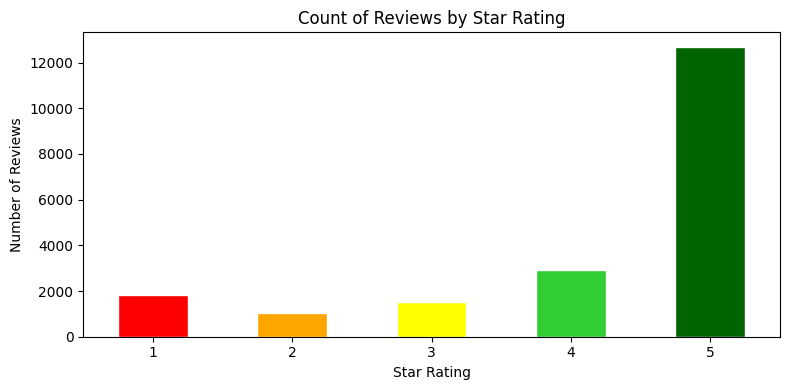

In [ ]:
print(df['Score'].value_counts().sort_index())

colors = ['red', 'orange', 'yellow', 'limegreen', 'darkgreen']

fig, ax = plt.subplots(figsize=(8, 4))
df['Score'].value_counts().sort_index().plot(
    kind='bar', ax=ax,
    title='Count of Reviews by Star Rating',
    color=colors, edgecolor='white'
)
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
ax.set_xticklabels([1, 2, 3, 4, 5], rotation=0)
plt.tight_layout()
plt.show()

## Cell 4: Create Sentiment Labels

The dataset only has star ratings so I had to convert them into sentiment labels myself.

I wrote a function that maps the scores like this:
- **4 or 5 stars → positive** because the customer is clearly happy
- **3 stars → neutral** because it's kind of mixed
- **1 or 2 stars → negative** because the customer is not happy

I then plotted the distribution of those labels so I could see how many reviews fall into each category.

Sentiment
positive    15595
negative     2886
neutral      1519
Name: count, dtype: int64


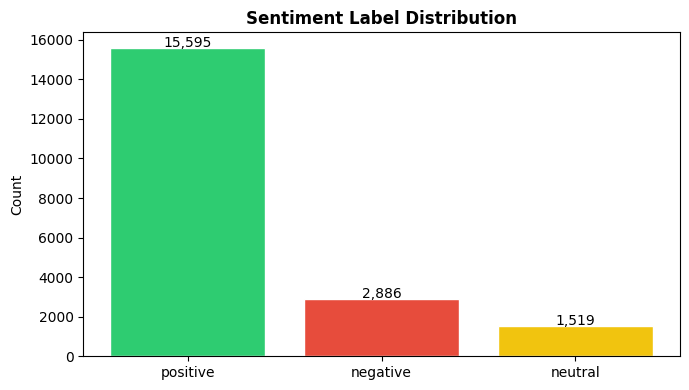

In [ ]:
def score_to_sentiment(score):
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

df['Sentiment'] = df['Score'].apply(score_to_sentiment)

print(df['Sentiment'].value_counts())

color_map = {'positive': '#2ecc71', 'neutral': '#f1c40f', 'negative': '#e74c3c'}
counts = df['Sentiment'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values,
              color=[color_map[s] for s in counts.index],
              edgecolor='white')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 50,
            f'{int(b.get_height()):,}', ha='center', fontsize=10)
ax.set_title('Sentiment Label Distribution', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Cell 5: Text Preprocessing

Before I can feed the reviews into a machine learning model I had to clean the text first. Raw text has a lot of noise in it that would mess up the results.

I wrote a function called clean_text that does the following things to every review:
1. Converts everything to lowercase so the same word doesn't get counted twice
2. Strips out any HTML tags since some Amazon reviews have them
3. Removes anything that isn't a letter like numbers and punctuation
4. Splits the text into individual words
5. Removes stop words like "the" and "is" that don't mean anything for sentiment
6. Lemmatizes each word so things like "running" become "run"

I used tqdm so I could see the progress bar while it was cleaning all 20,000 reviews. At the end I printed a before and after example just to make sure it was working right.

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

tqdm.pandas(desc='Cleaning')
df['Cleaned_Text'] = df['Text'].progress_apply(clean_text)

print('Before:', df['Text'].iloc[0][:200])
print('After: ', df['Cleaned_Text'].iloc[0][:200])

Cleaning:   0%|          | 0/20000 [00:00<?, ?it/s]

Before: Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  S
After:  tried couple brand gluten free sandwich cooky best bunch crunchy true texture real cooky gluten free might think filling make bit sweet mean satisfied sweet tooth sooner chocolate version glutino good


## Cell 6: VADER Baseline

Here I'm using VADER which is a rule-based sentiment tool that comes with nltk. It doesn't need any training which is why I'm using it as a baseline to compare my ML models against.

VADER gives back 4 scores for each review — neg, neu, pos, and compound. The compound score is the overall one and goes from -1 (most negative) to +1 (most positive).

I looped through all 20,000 reviews and ran VADER on each one, then merged those scores back into the main DataFrame.

To turn the compound score into a label I used these thresholds which come from the original VADER paper:
- **0.05 or higher → positive**
- **-0.05 or lower → negative**
- **anything in between → neutral**

At the end I printed the accuracy score and classification report so I can see how well VADER does. This number is my baseline — my ML models need to beat it.

In [ ]:
sia = SentimentIntensityAnalyzer()

sample_text = "This product is absolutely amazing, I love it so much!"
print(sia.polarity_scores(sample_text))

results = {}
for i, row in tqdm(df.iterrows(), total=len(df), desc='VADER scoring'):
    myID = row['review_id']
    text = row['Text']
    results[myID] = sia.polarity_scores(text)

vaders = pd.DataFrame(results).T.reset_index()
vaders.columns = ['review_id', 'neg', 'neu', 'pos', 'compound']
vaders['review_id'] = vaders['review_id'].astype(int)
df = df.merge(vaders, on='review_id', how='left')

def vader_label(compound):
    if compound >= 0.05:     return 'positive'
    elif compound <= -0.05:  return 'negative'
    else:                    return 'neutral'

df['vader_sentiment'] = df['compound'].apply(vader_label)

vader_acc = accuracy_score(df['Sentiment'], df['vader_sentiment'])
print(f'VADER Accuracy: {vader_acc:.3f}')
print(classification_report(df['Sentiment'], df['vader_sentiment']))

{'neg': 0.0, 'neu': 0.441, 'pos': 0.559, 'compound': 0.8709}


VADER scoring:   0%|          | 0/20000 [00:00<?, ?it/s]

VADER Accuracy: 0.798
              precision    recall  f1-score   support

    negative       0.56      0.40      0.47      2886
     neutral       0.14      0.04      0.06      1519
    positive       0.84      0.94      0.89     15595

    accuracy                           0.80     20000
   macro avg       0.51      0.46      0.47     20000
weighted avg       0.75      0.80      0.77     20000



## Cell 7: VADER Visualizations

I made two charts here to visualize how the VADER scores relate to the actual star ratings.

The first chart shows the average compound score for each star rating. You can see it goes from negative on the left for 1 star reviews all the way up to positive on the right for 5 star reviews which makes sense.

The second chart breaks it down into 3 separate plots for the positive, neutral, and negative scores so I can see how each one changes across the star ratings.

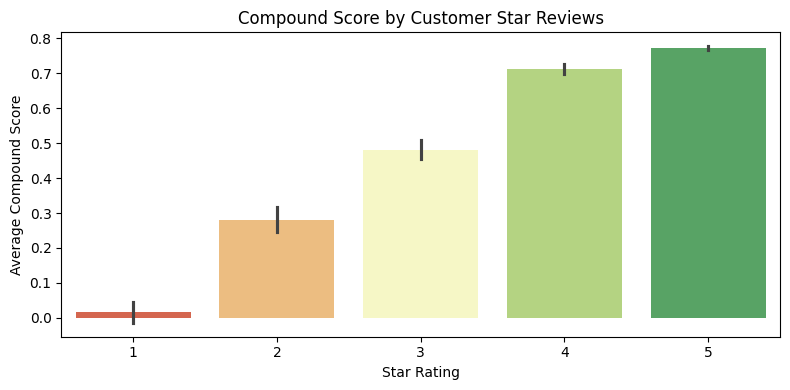

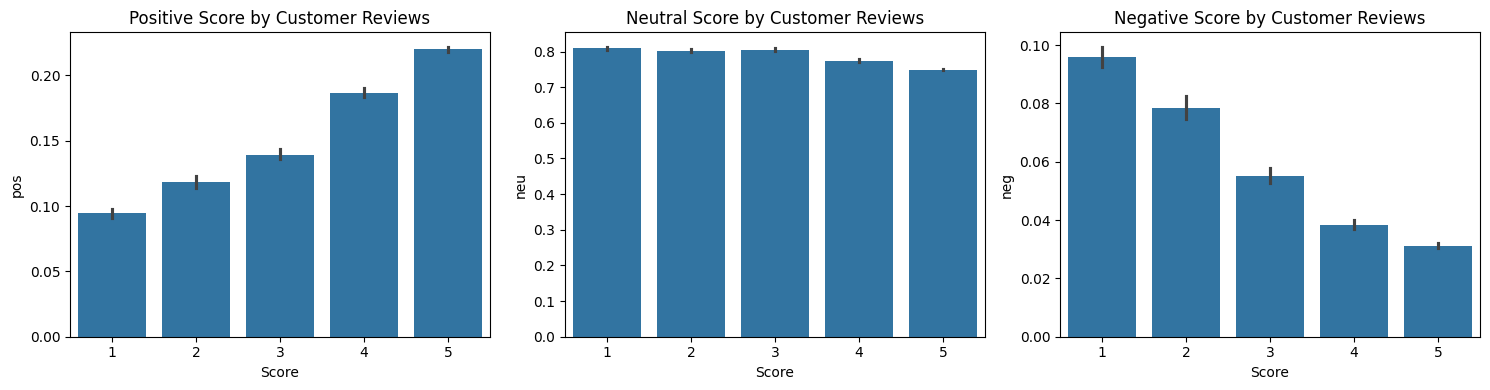

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='Score', y='compound', ax=ax, palette='RdYlGn')
ax.set_title('Compound Score by Customer Star Reviews')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Average Compound Score')
plt.tight_layout()
plt.show()

fig, assess = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=df, x='Score', y='pos', ax=assess[0])
sns.barplot(data=df, x='Score', y='neu', ax=assess[1])
sns.barplot(data=df, x='Score', y='neg', ax=assess[2])
assess[0].set_title('Positive Score by Customer Reviews')
assess[1].set_title('Neutral Score by Customer Reviews')
assess[2].set_title('Negative Score by Customer Reviews')
plt.tight_layout()
plt.show()

## Cell 8: Three Machine Learning Models

In this cell I'm training and comparing three different ML models to see which one does the best job at classifying the sentiment.

First I convert the cleaned text into numbers using TF-IDF. I'm using these settings:
- **max_features=20,000** to keep the top 20,000 most useful words
- **ngram_range=(1,2)** so it captures both single words and two word phrases
- **min_df=3** to ignore words that barely show up in the data
- **sublinear_tf=True** to reduce the effect of words that appear way too often

I split the data 80% for training and 20% for testing and used stratify=y to make sure the class balance is the same in both splits.

The three models I'm comparing are:
1. **Bernoulli Naive Bayes** — fast and simple, good with word features
2. **SVM** — good at finding the boundary between classes
3. **Logistic Regression** — usually the strongest performer on text data

For each one I trained it, made predictions on the test set, and printed the accuracy and classification report.

In [ ]:
X = df['Cleaned_Text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2),
                             min_df=3, sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'Train shape: {X_train_tfidf.shape}')
print(f'Test shape : {X_test_tfidf.shape}\n')

bnb = BernoulliNB()
bnb.fit(X_train_tfidf, y_train)
bnb_pred = bnb.predict(X_test_tfidf)
print(f'Bernoulli Naive Bayes Accuracy: {accuracy_score(y_test, bnb_pred):.3f}')
print(classification_report(y_test, bnb_pred))

svm = LinearSVC(max_iter=1000)
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)
print(f'SVM Accuracy: {accuracy_score(y_test, svm_pred):.3f}')
print(classification_report(y_test, svm_pred))

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_tfidf, y_train)
logreg_pred = logreg.predict(X_test_tfidf)
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, logreg_pred):.3f}')
print(classification_report(y_test, logreg_pred))

Train shape: (16000, 20000)
Test shape : (4000, 20000)

Bernoulli Naive Bayes Accuracy: 0.788
              precision    recall  f1-score   support

    negative       0.68      0.42      0.52       577
     neutral       0.23      0.23      0.23       304
    positive       0.85      0.91      0.88      3119

    accuracy                           0.79      4000
   macro avg       0.59      0.52      0.54      4000
weighted avg       0.78      0.79      0.78      4000

SVM Accuracy: 0.845
              precision    recall  f1-score   support

    negative       0.70      0.57      0.63       577
     neutral       0.42      0.17      0.24       304
    positive       0.88      0.96      0.92      3119

    accuracy                           0.84      4000
   macro avg       0.67      0.57      0.60      4000
weighted avg       0.82      0.84      0.83      4000

Logistic Regression Accuracy: 0.794
              precision    recall  f1-score   support

    negative       0.57      0.67

## Cell 9: Confusion Matrices and Model Comparison

Here I'm visualizing how each model performed using confusion matrices. Each matrix shows which sentiment classes the model got right and which ones it mixed up. The numbers on the diagonal are the correct predictions.

I also made a bar chart that puts all 4 approaches side by side — VADER, Naive Bayes, SVM, and Logistic Regression. The dashed line marks the VADER baseline so I can easily see how much the ML models improved over the rule-based approach.

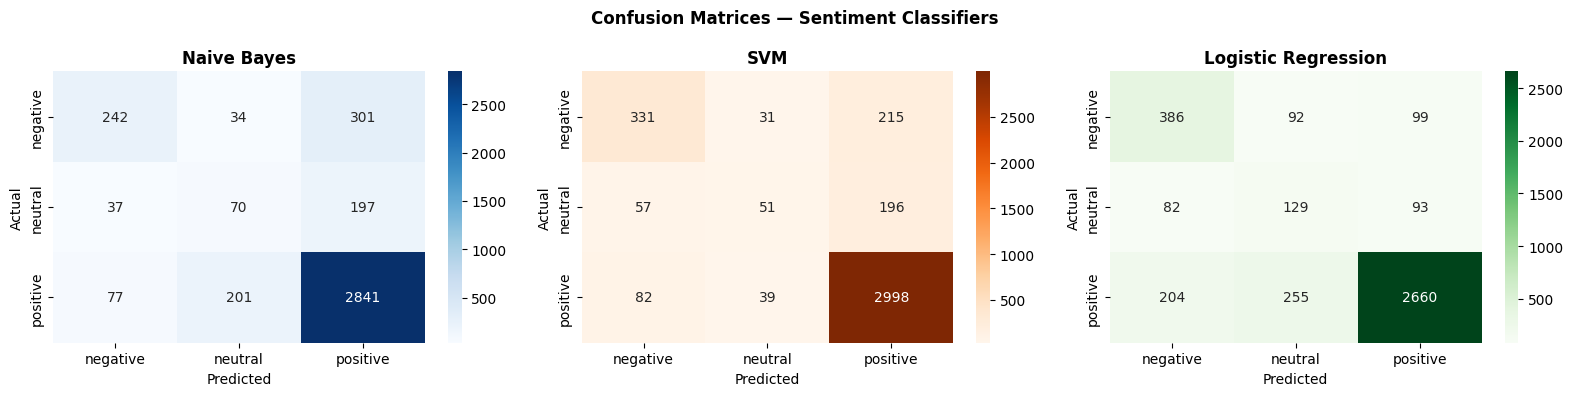

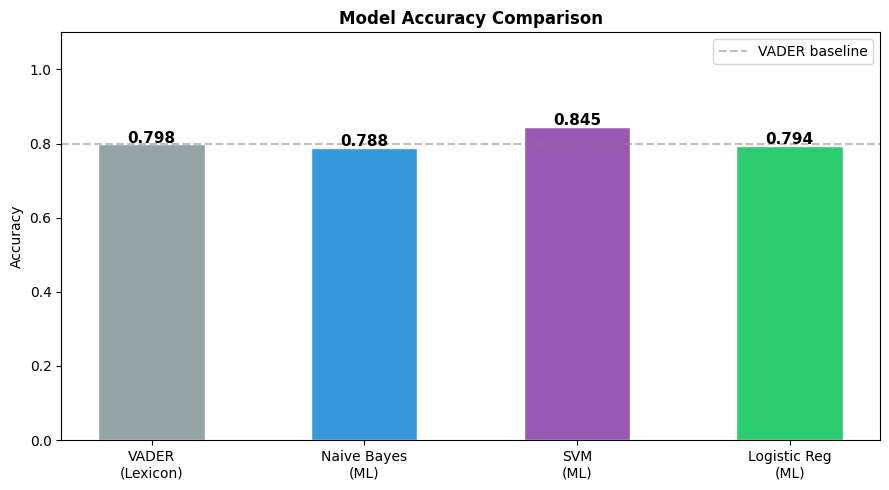

In [ ]:
labels = ['negative', 'neutral', 'positive']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion Matrices — Sentiment Classifiers', fontweight='bold')

for ax, pred, name, cmap in zip(
    axes,
    [bnb_pred, svm_pred, logreg_pred],
    ['Naive Bayes', 'SVM', 'Logistic Regression'],
    ['Blues', 'Oranges', 'Greens']
):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

model_names = ['VADER\n(Lexicon)', 'Naive Bayes\n(ML)', 'SVM\n(ML)', 'Logistic Reg\n(ML)']
accuracies = [
    accuracy_score(df['Sentiment'], df['vader_sentiment']),
    accuracy_score(y_test, bnb_pred),
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, logreg_pred)
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, accuracies,
              color=['#95a5a6', '#3498db', '#9b59b6', '#2ecc71'],
              edgecolor='white', width=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('Model Accuracy Comparison', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.axhline(y=accuracies[0], color='gray', linestyle='--', alpha=0.5, label='VADER baseline')
ax.legend()
plt.tight_layout()
plt.show()

## Cell 10: Star Rating Predictor

This cell is doing something harder than Cell 8. Instead of just classifying positive, neutral, or negative I'm trying to predict the exact star rating from 1 to 5 directly from the review text.

I used a sklearn Pipeline here which chains the TF-IDF vectorizer and Logistic Regression together into one step. This is cleaner and makes sure the vectorizer only learns from the training data and not the test data.

I'm evaluating it with two metrics:
- **Accuracy** — how often I got the exact right star rating
- **MAE (Mean Absolute Error)** — how many stars off I am on average. So an MAE of 0.8 means I'm usually less than 1 star away from the correct answer

I also plotted a confusion matrix to see where the model is making mistakes across the 5 star classes.

Rating Model Accuracy : 0.624
Mean Absolute Error   : 0.627 stars
              precision    recall  f1-score   support

           1       0.49      0.66      0.56       368
           2       0.23      0.29      0.25       209
           3       0.27      0.34      0.30       304
           4       0.32      0.42      0.37       581
           5       0.88      0.73      0.79      2538

    accuracy                           0.62      4000
   macro avg       0.44      0.49      0.46      4000
weighted avg       0.68      0.62      0.65      4000



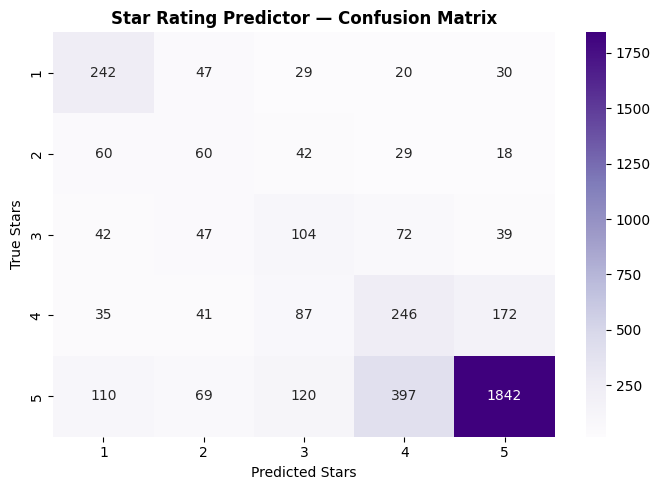

In [ ]:
X_rate = df['Cleaned_Text']
y_rate = df['Score']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_rate, y_rate, test_size=0.2, random_state=42, stratify=y_rate
)

rating_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20_000, ngram_range=(1, 2),
                              min_df=3, sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced',
                                 random_state=42))
])

rating_model.fit(X_train_r, y_train_r)
y_pred_r = rating_model.predict(X_test_r)

print(f'Rating Model Accuracy : {accuracy_score(y_test_r, y_pred_r):.3f}')
print(f'Mean Absolute Error   : {mean_absolute_error(y_test_r, y_pred_r):.3f} stars')
print(classification_report(y_test_r, y_pred_r))

fig, ax = plt.subplots(figsize=(7, 5))
cm_r = confusion_matrix(y_test_r, y_pred_r, labels=[1, 2, 3, 4, 5])
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Purples',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5], ax=ax)
ax.set_title('Star Rating Predictor — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted Stars')
ax.set_ylabel('True Stars')
plt.tight_layout()
plt.show()

## Cell 11: Live Prediction Demo

Here I wrote a function called predict_review that lets me test all the models I built on any new review text.

I pass in a review, it cleans the text, runs it through VADER, all three ML classifiers, and the star rating predictor, then prints all the results together so I can compare them side by side.

I tested it on three reviews — a clearly positive one, a neutral one, and a clearly negative one — just to show how each model handles different types of input.

In [ ]:
def predict_review(review_text):
    cleaned  = clean_text(review_text)
    vec      = vectorizer.transform([cleaned])
    compound = sia.polarity_scores(review_text)['compound']

    print('=' * 60)
    print(f'  Review : "{review_text[:70]}{"…" if len(review_text) > 70 else ""}"')
    print('-' * 60)
    print(f'  VADER        : {vader_label(compound)}  (compound={compound:.3f})')
    print(f'  Naive Bayes  : {bnb.predict(vec)[0]}')
    print(f'  SVM          : {svm.predict(vec)[0]}')
    print(f'  Logistic Reg : {logreg.predict(vec)[0]}')
    stars = rating_model.predict([cleaned])[0]
    print(f'  Stars        : {"★" * stars}{"☆" * (5 - stars)} ({stars}/5)')
    print('=' * 60)

predict_review("I love this product! Best thing I have ever bought.")
predict_review("It was okay, nothing special. Does the job I guess.")
predict_review("Terrible product. Arrived broken and smelled awful. Never again.")

  Review : "I love this product! Best thing I have ever bought."
------------------------------------------------------------
  VADER        : positive  (compound=0.866)
  Naive Bayes  : positive
  SVM          : positive
  Logistic Reg : positive
  Stars        : ★★★★★ (5/5)
  Review : "It was okay, nothing special. Does the job I guess."
------------------------------------------------------------
  VADER        : negative  (compound=-0.092)
  Naive Bayes  : positive
  SVM          : neutral
  Logistic Reg : neutral
  Stars        : ★★★☆☆ (3/5)
  Review : "Terrible product. Arrived broken and smelled awful. Never again."
------------------------------------------------------------
  VADER        : negative  (compound=-0.848)
  Naive Bayes  : positive
  SVM          : negative
  Logistic Reg : negative
  Stars        : ★☆☆☆☆ (1/5)
